In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [2]:
from scripts import style
style.mpl_apply()  

In [3]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

# Limpieza de datos

En esta seccion se estandarizo la base de datos para que no haya alumnos repetidos que inflen la calificacion promedio de un profesor, o de una materia, etc. como los alumnos que revalidan materias y aparecen dos veces en la base de datos. Por ejemplo, yo salgo 2 veces en Calculo, 2 veces en Calculo II, etc.

In [4]:
print(materias.info())
materias.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27788 entries, 0 to 27787
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CLAVEALUMNO           27788 non-null  int64  
 1   CLAVECARRERA          27788 non-null  object 
 2   anio                  27788 non-null  int64  
 3   CLAVESESION           27788 non-null  object 
 4   NUMORDEN              27788 non-null  int64  
 5   CLAVEVARIANTEMATERIA  27788 non-null  object 
 6   DESCRIBEMATERIA       27788 non-null  object 
 7   CALIFICACION          27788 non-null  object 
 8   CLAVEPROFESOR         26740 non-null  float64
dtypes: float64(1), int64(3), object(5)
memory usage: 1.9+ MB
None


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0


In [5]:
materias.loc[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
3173,175199,LAT,2021,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
5191,175199,LDS,2023,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,NaN
6258,175199,LAT,2022,OTOÑO,0,MAT1022,CÁLCULO I,10,24827.0
14587,175199,LDS,2023,OTOÑO,0,MAT2012,CÁLCULO II,10,NaN
20218,175199,LDS,2023,OTOÑO,0,MAT1022,CÁLCULO I,10,NaN
26000,175199,LAT,2023,PRIMAVERA,0,MAT2012,CÁLCULO II,10,23874.0
27589,175199,LAT,2022,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0


Hay NaNs en los profes porque son de las revalidadas

In [6]:
# IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,0,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,0,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,0,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,0,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


In [7]:
materias['NUMORDEN'].nunique()

1

In [8]:
# drop NUMORDEN column
materias.drop(columns=['NUMORDEN'], inplace=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


Estas ya son mis calificaciones estandarizadas, sin repeticiones de alumnos en las materias.

In [9]:
materias[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
15962,175199,LAT,2021,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
15963,175199,LAT,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0
15964,175199,LAT,2022,OTOÑO,MAT1022,CÁLCULO I,10,24827.0
15965,175199,LAT,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,23874.0


In [10]:
# count nans
materias['CLAVEPROFESOR'].isna().sum()

505

In [11]:
# drop the rows where CLAVEPROFESOR is nan
materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
# make the CLAVEPROFESOR column integer
materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)

Bien!

Estas es el numero de alumnos unicos por profesor:  
Hay profesores con 969 alumnos! Wow! y un minimo de 26,30.

In [12]:
# clave profesor nunique
profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
profes_value_counts

CLAVEPROFESOR
23452    969
23411    772
23152    726
24097    720
23852    719
        ... 
24328     40
21226     30
22472     30
21756     30
26078     26
Name: count, Length: 77, dtype: int64

# Imputacion de datos faltantes

En esta seccion se prueban distintos metodos de imputacion de calificaciones

Se va a decir que un salon es aquel que tiene el mismo profesor, materia, anio y periodo.

**Imputacion con KDE para no cambiar la distribucion de los que no tienen calificacion *asumiendo que estan debajo de 7.5***

In [13]:
profes_ids = materias['CLAVEPROFESOR'].unique()

In [14]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df


In [15]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE', constant_value=6.5, fallback='uniform'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

C:\Users\herie\AppData\Local\Temp\ipykernel_29092\3551422448.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
C:\Users\herie\AppData\Local\Temp\ipykernel_29092\3551422448.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
C:\Users\herie\AppData\Local\Temp\ipykernel_29092\3551422448.py:19: SettingWithCopyWarning: 

In [16]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
outlier

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
11445,171250,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8,22115,8.0,-0.098742,8.00,0.459688
18419,177578,LPM,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.8,22115,8.8,1.130048,8.80,0.777497
19590,178484,LEA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9,22115,9.0,1.437245,9.00,0.856950
20000,178914,LRP,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.4,22115,8.4,0.515653,8.40,0.618593
20402,179351,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.6,22115,7.6,-0.713137,7.60,0.300784
20853,179782,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.8,22115,7.8,-0.405939,7.80,0.380236
20908,179841,LPD,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,8.1,0.054857,8.10,0.499414
21092,180003,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,BV,22115,7.5,-0.866736,0.74,-2.424430
21214,180143,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,8.1,0.054857,8.10,0.499414
21372,180285,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.5,22115,8.5,0.669251,8.50,0.658319


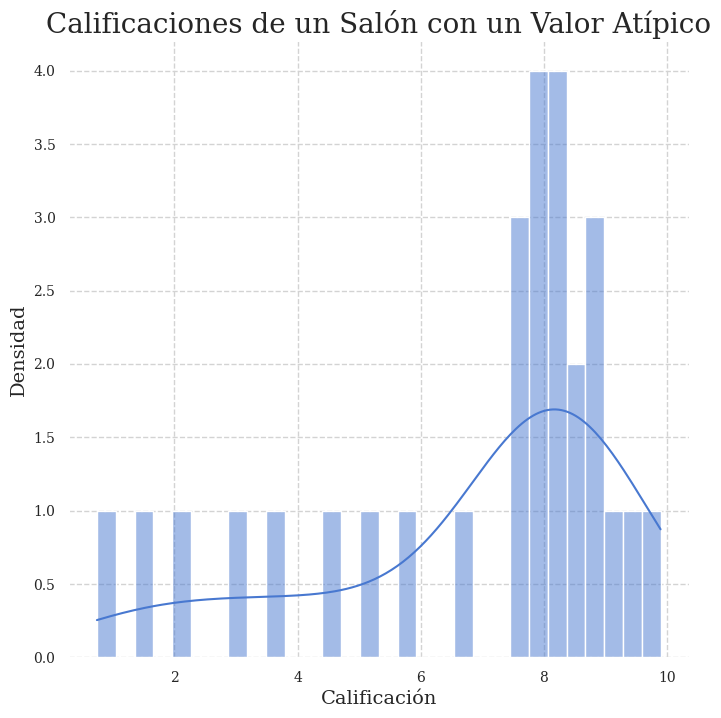

In [17]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
# plot impkde of outlier
sns.histplot(outlier['IMPKDE'], bins=30, kde=True)
plt.title('Calificaciones de un Salón con un Valor Atípico')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
plt.show()

# Pruebas de Hipotesis

In [18]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

In [19]:
# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

In [20]:
# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)

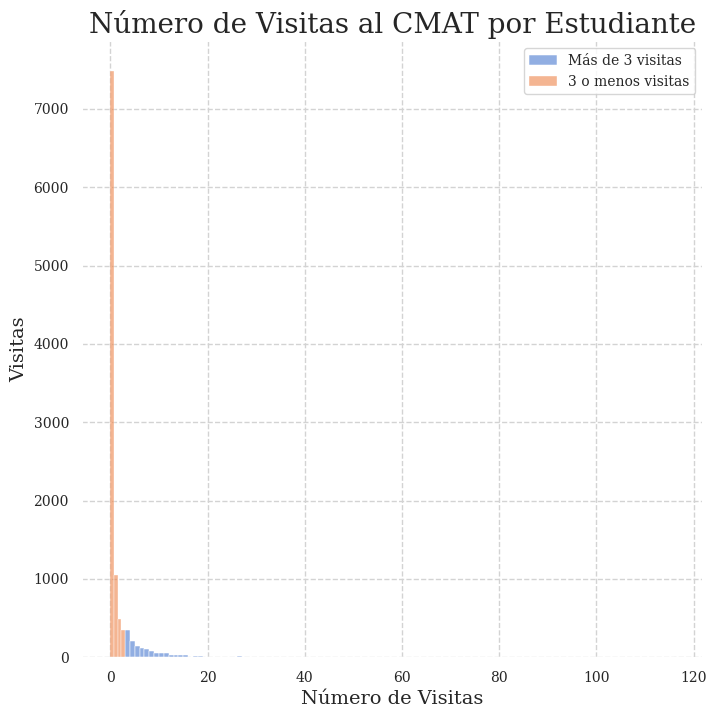

In [21]:
# density of VISITAS column
sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label='Más de 3 visitas')
sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label='3 o menos visitas')
plt.title('Número de Visitas al CMAT por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Visitas')
plt.legend()
plt.savefig('visualizations/pdfs/numeroVisitasCMATEstudiante.pdf', bbox_inches='tight')

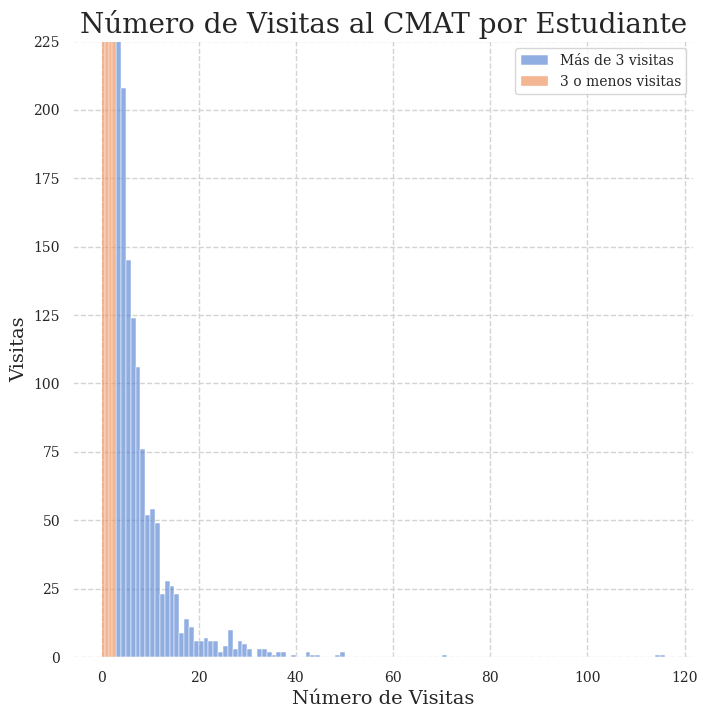

In [22]:
# density of VISITAS column
sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label='Más de 3 visitas')
sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label='3 o menos visitas')
plt.title('Número de Visitas al CMAT por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Visitas')
plt.legend()
plt.ylim(0, 225)
plt.savefig('visualizations/pdfs/numeroVisitasCMATEstudiante.pdf', bbox_inches='tight')

In [23]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

In [24]:
materias[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
15962,175199,LAT,2021,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835,13
15963,175199,LAT,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897,13
15964,175199,LAT,2022,OTOÑO,MAT1022,CÁLCULO I,10,24827,13
15965,175199,LAT,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,23874,13


Agregamos las visitas registradas al CMAT por id

In [25]:
# add the timmes each id appears as a new column 'asesoria_count' in asesorias

materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453,0
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897,0
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446,0
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149,0


In [27]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

C:\Users\herie\AppData\Local\Temp\ipykernel_29092\2741904170.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
C:\Users\herie\AppData\Local\Temp\ipykernel_29092\2741904170.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
C:\Users\herie\AppData\Local\Temp\ipykernel_29092\2741904170.py:19: SettingWithCopyWarning: 

In [ ]:
salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')].head()

## Comparacion Global

In [28]:
ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0,5.355,-0.639014,0.5,-2.346103
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.5,-2.346103
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.3,-0.513402
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.5,0.326586
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.8,0.441130


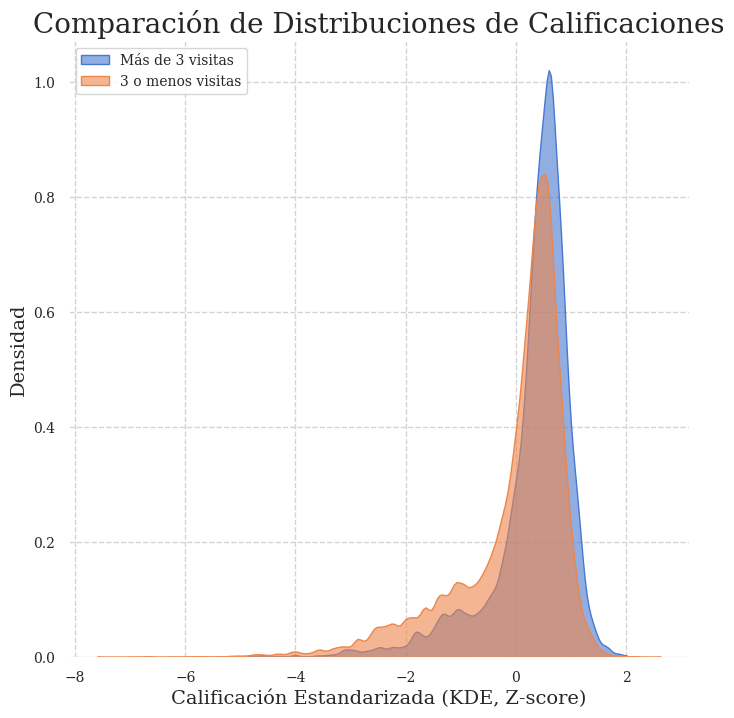

In [29]:
# separate the ultramerge into three dataframes: one with VISITAS>3 and one with VISITAS<=3
ultramerge_mas_de_3 = ultramerge[ultramerge['VISITAS'] > 3]
ultramerge_menos_3 = ultramerge[ultramerge['VISITAS'] <= 3]

# compare the distribution of impkedz between the two dataframes
sns.kdeplot(ultramerge_mas_de_3['IMPKDE_Z'], cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(ultramerge_menos_3['IMPKDE_Z'], cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de Distribuciones de Calificaciones')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')  
plt.ylabel('Densidad')
plt.legend()
plt.show()

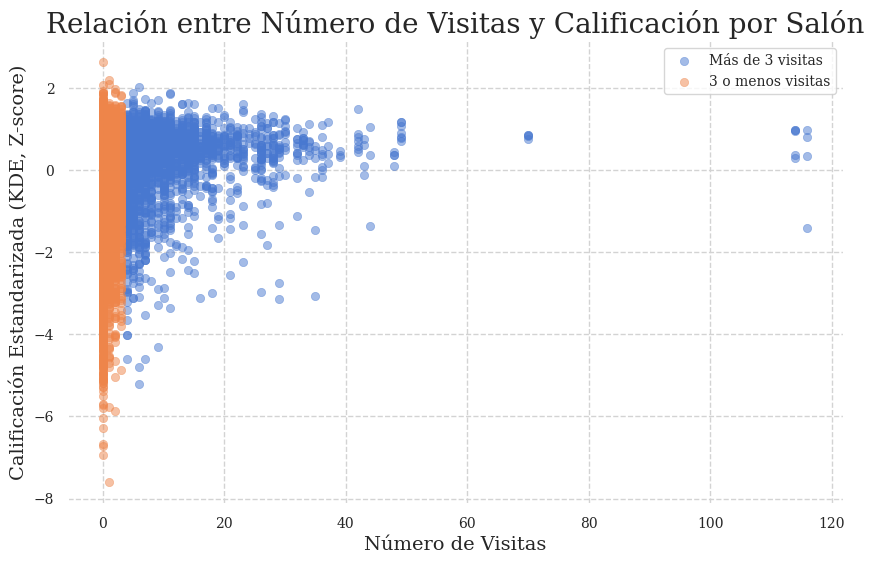

In [30]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_mas_de_3, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_menos_3, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)
plt.title('Relación entre Número de Visitas y Calificación por Salón')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()
plt.show()

por promedio de calificaciones del estudiante

In [31]:
# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means = ultramerge.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means = ultramerge_means.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge_means

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
0,88493,-2.346103,0
1,92988,0.930129,3
2,94286,-0.034072,3
3,111083,0.180808,0
4,140079,1.012304,49
...,...,...,...
10408,402894,0.611009,0
10409,403107,0.847081,0
10410,403205,-0.870484,0
10411,403514,0.923041,0


In [32]:
ultramerge_means

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
0,88493,-2.346103,0
1,92988,0.930129,3
2,94286,-0.034072,3
3,111083,0.180808,0
4,140079,1.012304,49
...,...,...,...
10408,402894,0.611009,0
10409,403107,0.847081,0
10410,403205,-0.870484,0
10411,403514,0.923041,0


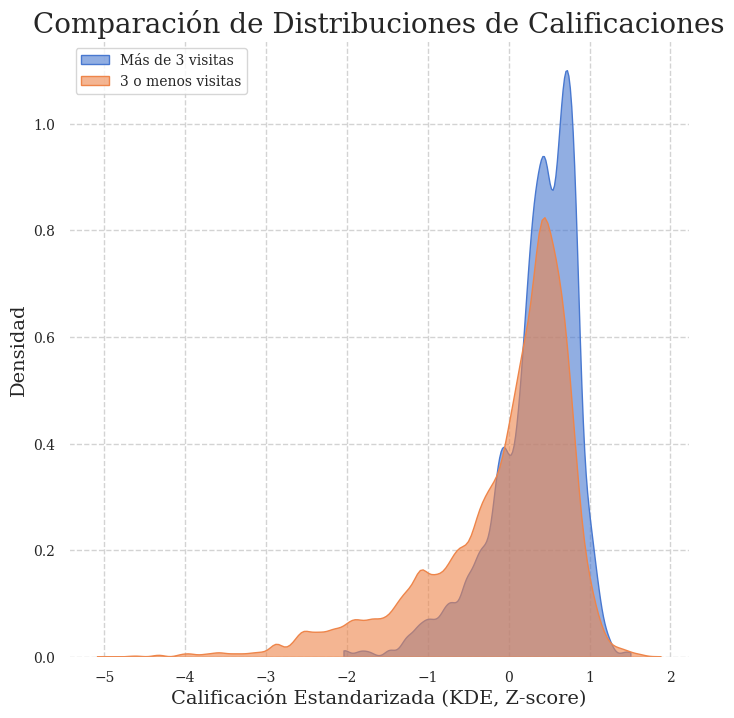

In [33]:
# separate the ultramerge into three dataframes: one with VISITAS>3 and one with VISITAS<=3
ultramerge_means_mas_de_3 = ultramerge_means[ultramerge_means['VISITAS'] > 3]
ultramerge_means_menos_3 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]

# compare the distribution of impkedz between the two dataframes
sns.kdeplot(ultramerge_means_mas_de_3['MEAN_IMPKDE_Z'], cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(ultramerge_means_menos_3['MEAN_IMPKDE_Z'], cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de Distribuciones de Calificaciones')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')  
plt.ylabel('Densidad')
plt.legend()
plt.show()

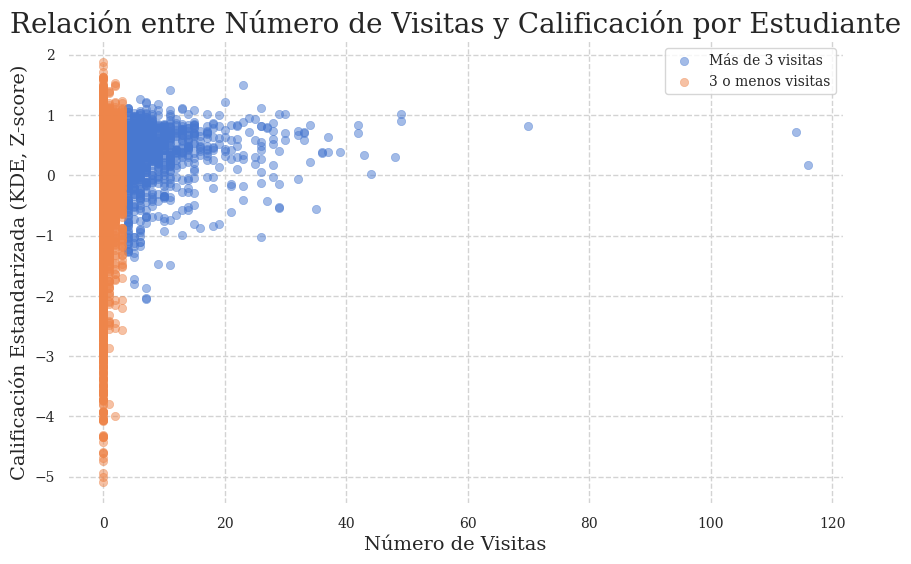

In [34]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)


plt.title('Relación entre Número de Visitas y Calificación por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()
plt.show()

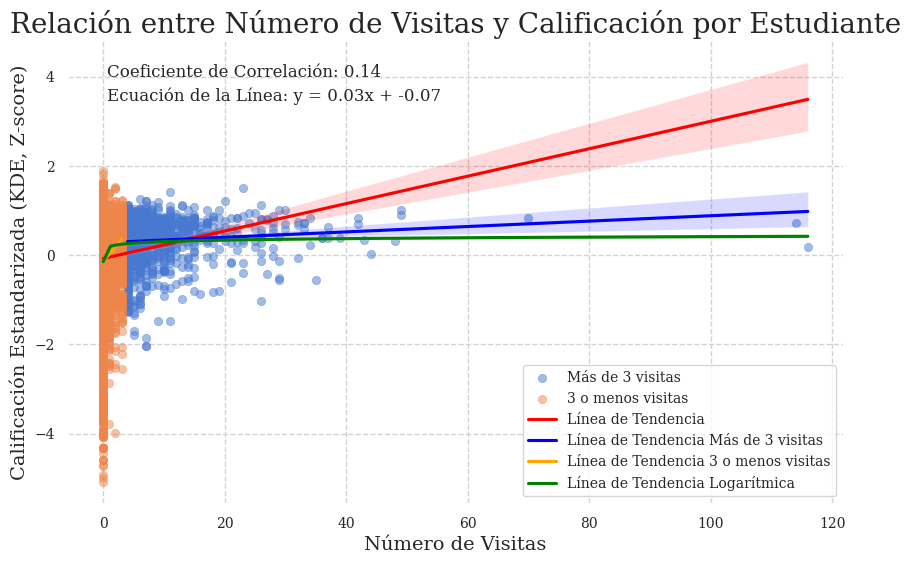

In [35]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)

# add a regression line
sns.regplot(data=ultramerge_means, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='red', line_kws={'label':"Línea de Tendencia"}, label='Línea de Tendencia')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='blue', line_kws={'label':"Línea de Tendencia Más de 3 visitas"}, label='Línea de Tendencia Más de 3 visitas')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='orange', line_kws={'label':"Línea de Tendencia 3 o menos visitas"}, label='Línea de Tendencia 3 o menos visitas')

# get the slope and intercept of the regression line
import statsmodels.api as sm
X = sm.add_constant(ultramerge_means['VISITAS'])
model = sm.OLS(ultramerge_means['MEAN_IMPKDE_Z'], X).fit()
slope = model.params['VISITAS']
intercept = model.params['const']
plt.text(0.05, 0.90, f'Ecuación de la Línea: y = {slope:.2f}x + {intercept:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')


# get the correlation coefficient
corr = ultramerge_means['VISITAS'].corr(ultramerge_means['MEAN_IMPKDE_Z'])
plt.text(0.05, 0.95, f'Coeficiente de Correlación: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# it is like a logarithmic relationship
# change the 0 to 0.1 to avoid log(0)
ultramerge_logs = ultramerge_means.copy()
ultramerge_logs['VISITAS'] = ultramerge_logs['VISITAS'].replace(0, 0.001)
sns.regplot(data=ultramerge_logs, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='green', line_kws={'label':"Línea de Tendencia Logarítmica"}, label='Línea de Tendencia Logarítmica', logx=True)

plt.title('Relación entre Número de Visitas y Calificación por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()
plt.show()

In [36]:
# view the highest MEAN_IMPKDE_Z
ultramerge_means.sort_values(by='MEAN_IMPKDE_Z', ascending=False).head(10)

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
4481,171487,1.877836,0
6836,177125,1.814297,0
6898,177284,1.712288,0
9722,184556,1.626334,0
9193,183171,1.626334,0
9680,184438,1.626334,0
7197,177888,1.610280,0
5661,174246,1.605498,0
3985,170487,1.595618,0
9640,184349,1.561327,0


In [37]:
ultramerge[ultramerge['CLAVEALUMNO'] == 181475]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
8811,181475,LPO,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.9,22115,2,9.9,2.819633,9.9,1.214485


In [38]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
outlier
# IT IS CLA

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
11445,171250,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8,22115,0,8.0,-0.098742,8.00,0.459688
18419,177578,LPM,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.8,22115,0,8.8,1.130048,8.80,0.777497
19590,178484,LEA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9,22115,0,9.0,1.437245,9.00,0.856950
20000,178914,LRP,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.4,22115,7,8.4,0.515653,8.40,0.618593
20402,179351,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.6,22115,1,7.6,-0.713137,7.60,0.300784
20853,179782,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.8,22115,1,7.8,-0.405939,7.80,0.380236
20908,179841,LPD,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,0,8.1,0.054857,8.10,0.499414
21092,180003,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,BV,22115,1,7.5,-0.866736,0.74,-2.424430
21214,180143,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,7,8.1,0.054857,8.10,0.499414
21372,180285,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.5,22115,2,8.5,0.669251,8.50,0.658319


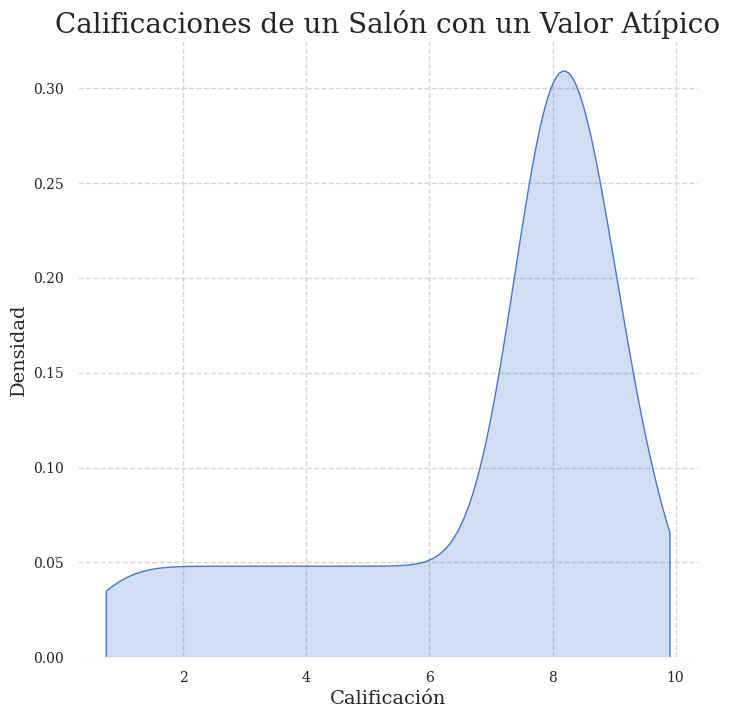

In [39]:
# plot impkde of outlier
sns.kdeplot(outlier['IMPKDE'], cut=0, bw_adjust=0.5, fill=True)
plt.title('Calificaciones de un Salón con un Valor Atípico')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
plt.show()

# Diferencia de medias

T-statistic: 22.608653895634607, P-value: 3.919911663573942e-100


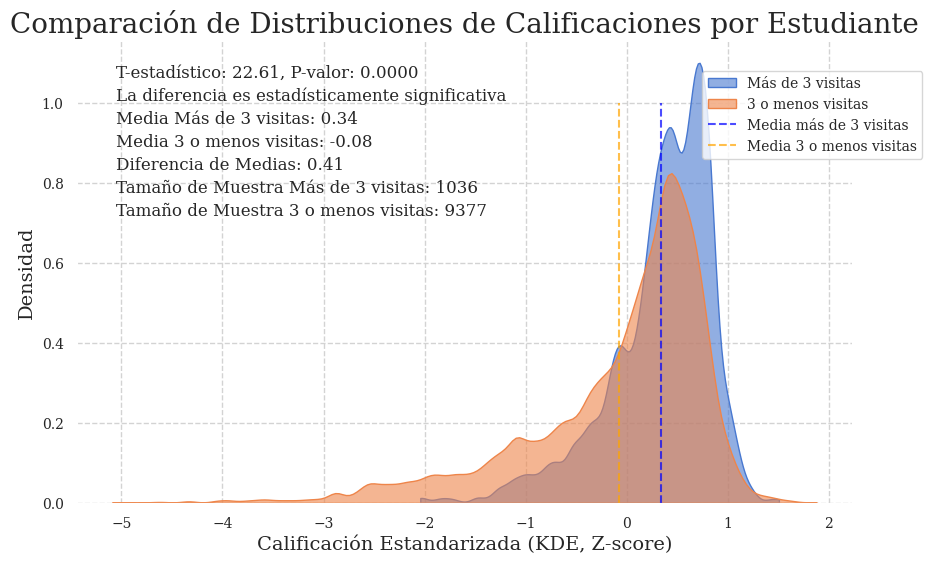

In [40]:
# compare the zscore of each group and test the difference of means

group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z']
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z']
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de Distribuciones de Calificaciones por Estudiante')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

plt.text(0.05, 0.95, f'T-estadístico: {t_stat:.2f}, P-valor: {p_value:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
# if p_value < 0.05, add a note that the difference is statistically significant
if p_value < 0.05:
    plt.text(0.05, 0.90, 'La diferencia es estadísticamente significativa', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.85, f'Media Más de 3 visitas: {group1.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.80, f'Media 3 o menos visitas: {group2.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.75, f'Diferencia de Medias: {group1.mean() - group2.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.70, f'Tamaño de Muestra Más de 3 visitas: {len(group1)}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.65, f'Tamaño de Muestra 3 o menos visitas: {len(group2)}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')    

plt.vlines(x=group1.mean(), ymin=0, ymax=1, colors='blue', linestyles='--', label='Media más de 3 visitas', alpha=0.7)
plt.vlines(x=group2.mean(), ymin=0, ymax=1, colors='orange', linestyles='--', label='Media 3 o menos visitas', alpha=0.7)
# legend top right but outside the plot
plt.legend(loc='upper right', bbox_to_anchor=(1.1, .95))
plt.savefig('visualizations/pdfs/comparacionDistribucionesCalificacionesEstudiantesVisitastext.pdf', bbox_inches='tight')
plt.show()

T-statistic: 22.608653895634607, P-value: 3.919911663573942e-100


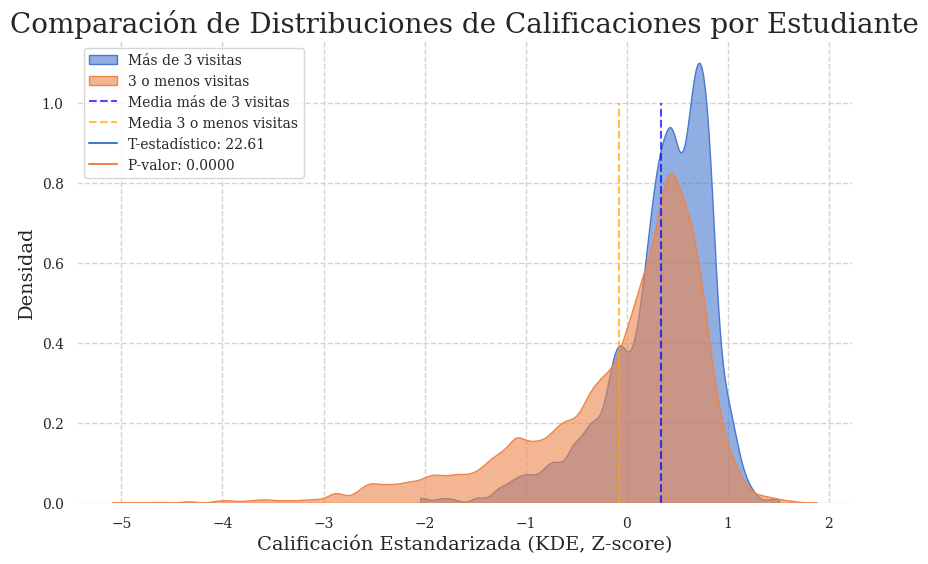

In [41]:
# compare the zscore of each group and test the difference of means
group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z']
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z']
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de Distribuciones de Calificaciones por Estudiante')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

# if p_value < 0.05, add a note that the difference is statistically significant


plt.vlines(x=group1.mean(), ymin=0, ymax=1, colors='blue', linestyles='--', label='Media más de 3 visitas', alpha=0.7)
plt.vlines(x=group2.mean(), ymin=0, ymax=1, colors='orange', linestyles='--', label='Media 3 o menos visitas', alpha=0.7)


label_text = f'T-estadístico: {t_stat:.2f}'
labeltext2 = f'P-valor: {p_value:.4f}'
plt.plot([], [], label=label_text)
plt.plot([], [], label=labeltext2)
# legend top right but outside the plot
plt.legend(loc='upper left')
plt.savefig('visualizations/pdfs/comparacionDistribucionesCalificacionesEstudiantesVisitas.pdf', bbox_inches='tight')
plt.show()

T-statistic: 24.33805733639584, P-value: 1.652387366172946e-124


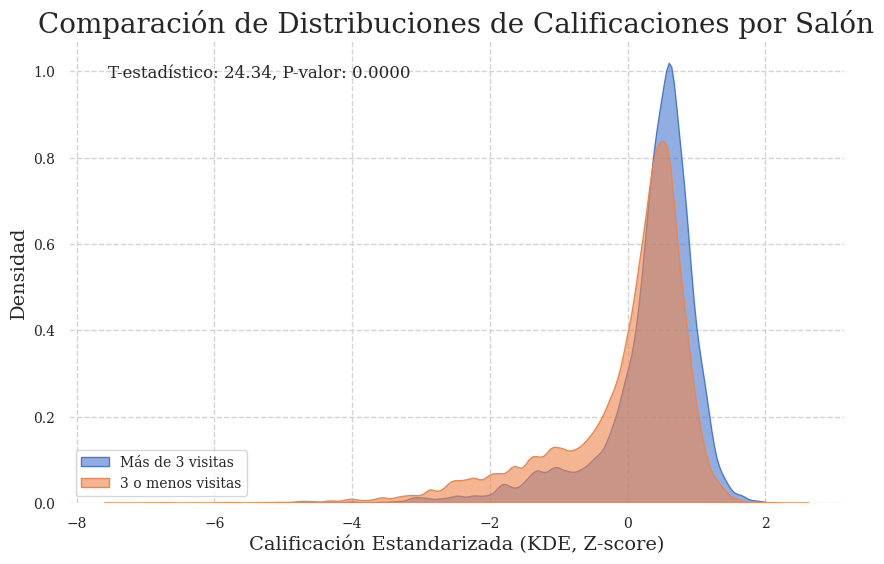

In [42]:
# compare the zscore of each group and test the difference of means
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z']
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z']
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de Distribuciones de Calificaciones por Salón')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')
plt.legend()
plt.text(0.05, 0.95, f'T-estadístico: {t_stat:.2f}, P-valor: {p_value:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.savefig('visualizations/pdfs/comparacionDistribucionesCalificacionesSalonVisitas.pdf', bbox_inches='tight')
plt.show()

# Diferencia de Medianas

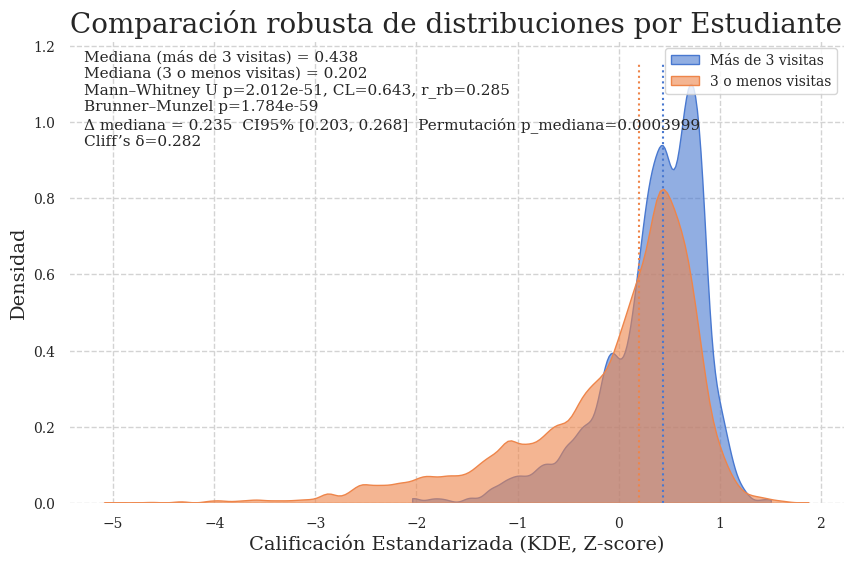

In [43]:


# Split groups
group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
n1, n2 = len(group1), len(group2)

# 1) Mann–Whitney U (Wilcoxon rank-sum)
U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
U_star = max(U, n1*n2 - U)                       # for CL
CL = U_star / (n1*n2)                            # common-language effect size
r_rb = 2*CL - 1                                  # rank-biserial correlation

# 2) Brunner–Munzel
bm_stat, p_bm = stats.brunnermunzel(group1, group2, alternative='two-sided')

# 3) Robust median shift with bootstrap CI
def bootstrap_diff_median(x, y, B=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(B, float)
    n1, n2 = len(x), len(y)
    for b in range(B):
        xb = rng.choice(x, n1, replace=True)
        yb = rng.choice(y, n2, replace=True)
        diffs[b] = np.median(xb) - np.median(yb)
    ci = np.quantile(diffs, [0.025, 0.975])
    return np.median(x) - np.median(y), ci, diffs

dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=8000, seed=42)

# 4) Permutation test on the median difference
def stat_median(x, y):
    return np.median(x) - np.median(y)

perm = stats.permutation_test((group1, group2), stat_median,
                              n_resamples=5000, alternative='two-sided',
                              random_state=42)
p_perm_med = perm.pvalue

# 5) Cliff's delta (approx if very large)
def cliffs_delta(x, y, max_pairs=5_000_000, seed=0):
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    rng = np.random.default_rng(seed)
    if n1*n2 > max_pairs:
        m = int(np.sqrt(max_pairs))
        X = x[rng.integers(0, n1, m)]
        Y = y[rng.integers(0, n2, m)]
    else:
        X, Y = x, y
    cmp = X[:, None] - Y[None, :]
    gt = np.sum(cmp > 0)
    lt = np.sum(cmp < 0)
    return (gt - lt) / (X.size * Y.size)

delta = cliffs_delta(group1, group2)

# ---- Plot with medians and robust stats
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')

m1, m2 = np.median(group1), np.median(group2)
plt.vlines([m1, m2], ymin=0, ymax=plt.gca().get_ylim()[1], colors=['C0','C1'],
           linestyles=':', linewidth=1.5)
plt.title('Comparación robusta de distribuciones por Estudiante')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

text = (
    f"Mediana (más de 3 visitas) = {m1:.3f}\n"
    f"Mediana (3 o menos visitas) = {m2:.3f}\n"
    f"Mann–Whitney U p={p_mw:.4g}, CL={CL:.3f}, r_rb={r_rb:.3f}\n"
    f"Brunner–Munzel p={p_bm:.4g}\n"
    f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
    f"Permutación p_mediana={p_perm_med:.4g}\n"
    f"Cliff’s δ={delta:.3f}"
)
plt.text(0.02, 0.98, text, transform=plt.gca().transAxes, va='top', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.savefig('visualizations/pdfs/comparacion_robusta_visitas.pdf', bbox_inches='tight')
plt.show()


In [44]:
text

'Mediana (más de 3 visitas) = 0.438\nMediana (3 o menos visitas) = 0.202\nMann–Whitney U p=2.012e-51, CL=0.643, r_rb=0.285\nBrunner–Munzel p=1.784e-59\nΔ mediana = 0.235  CI95% [0.203, 0.268]  Permutación p_mediana=0.0003999\nCliff’s δ=0.282'

Evidence of a real but moderate shift upward for VISITAS>3.

**Interpretation**

* **Direction:** Group >3 has higher location. Median shift (\Delta_{50} = 0.237) (in your Z units). CI(_{95%}) ([0.204, 0.281]) excludes 0.
* **Stochastic dominance:** Mann–Whitney (p=3.2\times10^{-50}); Brunner–Munzel (p=2.0\times10^{-57}). Very small (p) due to large (n); focus on effect sizes.
* **Magnitude:** Common-language (CL=0.641) ⇒ a random obs. from VISITAS>3 exceeds one from ≤3 **64.1%** of the time.
  Rank-biserial (r_{rb}=0.282) and Cliff’s (\delta=0.283) both indicate a **small-to-moderate** effect.
  Normal-approx conversion (d\approx \sqrt{2},\Phi^{-1}(CL)\approx 0.52) (medium).
* **Robustness:** Permutation test on the median (p=4.0\times10^{-4}) aligns with ranks.

**Reporting text (concise)**
“Relative to ≤3 visitas, the >3 group shows higher scores: median difference (0.237) [0.204, 0.281]. Mann–Whitney (p<10^{-49}), Brunner–Munzel (p<10^{-56}), probability-of-superiority (0.641), Cliff’s (\delta=0.283). Results are consistent under a permutation test on the median.”

**Checks before finalizing**

* Independence and consistent measurement across groups.
* Ties: if heavy, note exact vs asymptotic method.
* Unequal spreads: cite BM as primary.
* Multiple comparisons: adjust if you run many tests.
* Add the Hodges–Lehmann shift (pseudo-median) for MWU if desired.

**Actionable add-ons**

* Plot a **quantile shift function** to show where the differences concentrate.
* Report (n_1,n_2), median(IQR) per group, and the above effect sizes.

[
\boxed{\text{Effect size: }CL=0.641;\Rightarrow;r_{rb}=2CL-1=0.282;\approx;d;0.52;;\Delta_{50}=0.237;[0.204,0.281]}
]


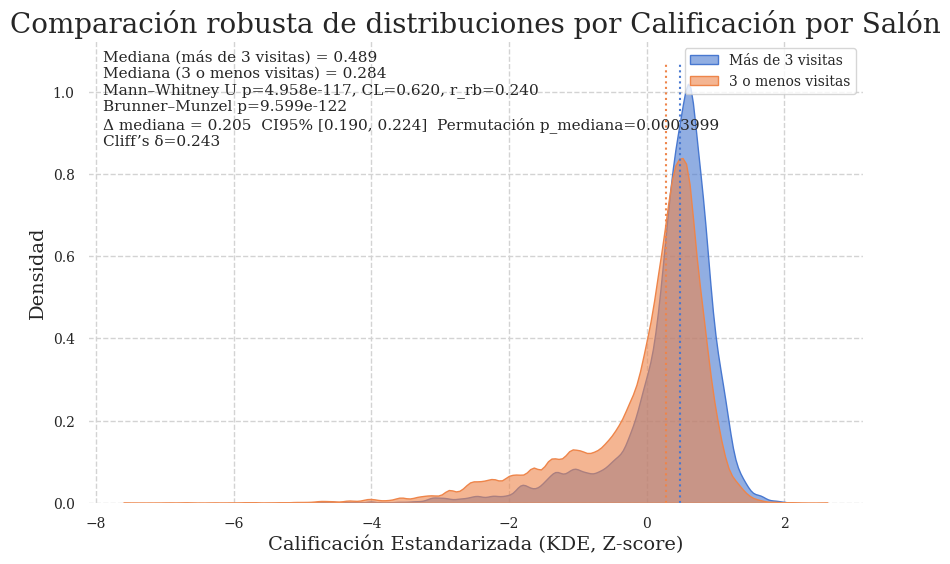

In [45]:
# Split groups
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z'].dropna().to_numpy()
n1, n2 = len(group1), len(group2)

# 1) Mann–Whitney U (Wilcoxon rank-sum)
U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
U_star = max(U, n1*n2 - U)                       # for CL
CL = U_star / (n1*n2)                            # common-language effect size
r_rb = 2*CL - 1                                  # rank-biserial correlation

# 2) Brunner–Munzel
bm_stat, p_bm = stats.brunnermunzel(group1, group2, alternative='two-sided')

# 3) Robust median shift with bootstrap CI
def bootstrap_diff_median(x, y, B=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(B, float)
    n1, n2 = len(x), len(y)
    for b in range(B):
        xb = rng.choice(x, n1, replace=True)
        yb = rng.choice(y, n2, replace=True)
        diffs[b] = np.median(xb) - np.median(yb)
    ci = np.quantile(diffs, [0.025, 0.975])
    return np.median(x) - np.median(y), ci, diffs

dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=8000, seed=42)

# 4) Permutation test on the median difference
def stat_median(x, y):
    return np.median(x) - np.median(y)

perm = stats.permutation_test((group1, group2), stat_median,
                              n_resamples=5000, alternative='two-sided',
                              random_state=42)
p_perm_med = perm.pvalue

# 5) Cliff's delta (approx if very large)
def cliffs_delta(x, y, max_pairs=5_000_000, seed=0):
    """
    The cliff's delta effect size measure, if the number of pairs is too large, it uses a random sample.
    """
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    rng = np.random.default_rng(seed)
    if n1*n2 > max_pairs:
        m = int(np.sqrt(max_pairs))
        X = x[rng.integers(0, n1, m)]
        Y = y[rng.integers(0, n2, m)]
    else:
        X, Y = x, y
    cmp = X[:, None] - Y[None, :]
    gt = np.sum(cmp > 0)
    lt = np.sum(cmp < 0)
    return (gt - lt) / (X.size * Y.size)

delta = cliffs_delta(group1, group2)

# ---- Plot with medians and robust stats
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')

m1, m2 = np.median(group1), np.median(group2)
plt.vlines([m1, m2], ymin=0, ymax=plt.gca().get_ylim()[1], colors=['C0','C1'],
           linestyles=':', linewidth=1.5)
plt.title('Comparación robusta de distribuciones por Calificación por Salón')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

text = (
    f"Mediana (más de 3 visitas) = {m1:.3f}\n"
    f"Mediana (3 o menos visitas) = {m2:.3f}\n"
    f"Mann–Whitney U p={p_mw:.4g}, CL={CL:.3f}, r_rb={r_rb:.3f}\n"
    f"Brunner–Munzel p={p_bm:.4g}\n"
    f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
    f"Permutación p_mediana={p_perm_med:.4g}\n"
    f"Cliff’s δ={delta:.3f}"
)
plt.text(0.02, 0.98, text, transform=plt.gca().transAxes, va='top', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.savefig('visualizations/pdfs/comparacion_robusta_visitas.pdf', bbox_inches='tight')
plt.show()


# Z promedio por estudiatne

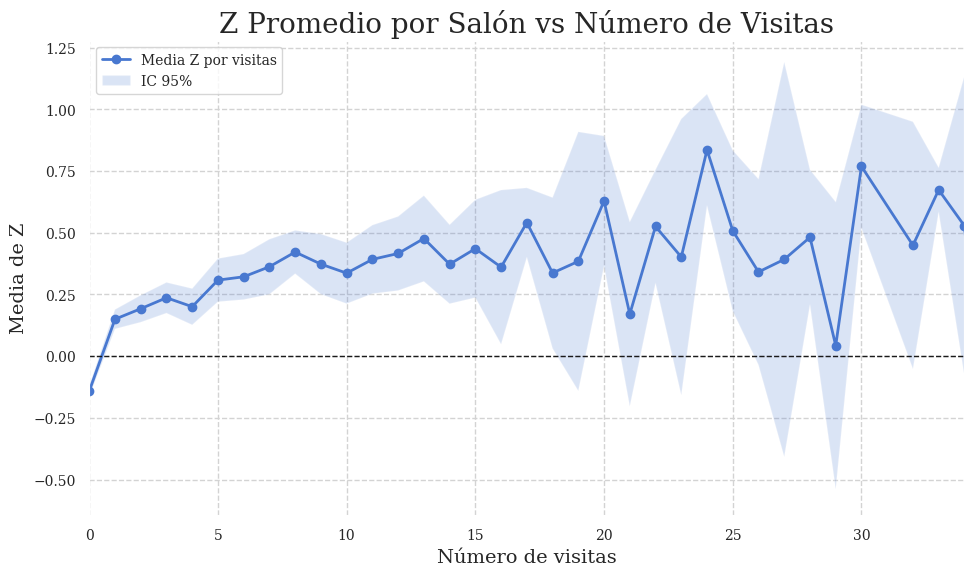

In [46]:
# agrupa por VISITAS y calcula media y error estándar
df = ultramerge_means[['VISITAS','MEAN_IMPKDE_Z']].dropna().copy()
agg = df.groupby('VISITAS')['MEAN_IMPKDE_Z'].agg(['mean','count','std'])
agg['se'] = agg['std'] / np.sqrt(agg['count'])
# intervalo de confianza 95% aproximado
agg['lo'] = agg['mean'] - 1.96*agg['se']
agg['hi'] = agg['mean'] + 1.96*agg['se']

plt.figure(figsize=(10,6))
plt.plot(agg.index, agg['mean'], marker='o', linewidth=2, label='Media Z por visitas')
plt.fill_between(agg.index, agg['lo'], agg['hi'], alpha=0.2, label='IC 95%')
plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlabel('Número de visitas')
plt.ylabel('Media de Z')
plt.title('Z Promedio por Salón vs Número de Visitas')
plt.legend()
plt.tight_layout()
plt.xlim(0, 34)
plt.savefig('visualizations/pdfs/z_vs_visitas_linea.pdf', bbox_inches='tight')
plt.show()
